In [ ]:
#import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix,classification_report,accuracy_score, precision_score, roc_auc_score,roc_curve

In [ ]:
#Load the dataset
df=pd.read_csv('/content/Student_Performance.csv')

In [ ]:
df.head()

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,Yes,9,1,91.0
1,4,82,No,4,2,65.0
2,8,51,Yes,7,2,45.0
3,5,52,Yes,5,2,36.0
4,7,75,No,8,5,66.0


In [ ]:
df.shape

(10000, 6)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Hours Studied                     10000 non-null  int64  
 1   Previous Scores                   10000 non-null  int64  
 2   Extracurricular Activities        10000 non-null  object 
 3   Sleep Hours                       10000 non-null  int64  
 4   Sample Question Papers Practiced  10000 non-null  int64  
 5   Performance Index                 10000 non-null  float64
dtypes: float64(1), int64(4), object(1)
memory usage: 468.9+ KB


In [ ]:
df.isnull().sum()

,0
Hours Studied,0
Previous Scores,0
Extracurricular Activities,0
Sleep Hours,0
Sample Question Papers Practiced,0
Performance Index,0


In [ ]:
print("No of duplicate rows:",df.duplicated().sum())

No of duplicate rows: 127


In [ ]:
# Feature summary
numerical_features = df.select_dtypes(include=['int64','float64']).columns
categorical_features = df.select_dtypes(include=['object']).columns
print("Feature Summary:\n")
print("Numerical Features:")
for col in numerical_features:
    print("-", col)
print("\nCategorical Features:")
for col in categorical_features:
    print("-", col)

Feature Summary:

Numerical Features:
- Hours Studied
- Previous Scores
- Sleep Hours
- Sample Question Papers Practiced
- Performance Index

Categorical Features:
- Extracurricular Activities


In [ ]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df.columns = df.columns.str.strip()  # Strip whitespace from column names
df['Extracurricular Activities'] = le.fit_transform(
    df['Extracurricular Activities']
)

In [ ]:
# Target Column Encoding
# Convert Performance Index into binary classes
df['Performance Category'] = (df['Performance Index'] >= 50).astype(int)

print("Target column Performance Category encoded successfully")

Target column Performance Category encoded successfully


In [ ]:
# Separate features and target
x=df.iloc[:,:-1]
y=df.iloc[:,-1]
print("Features (X) and target (y) separated successfully")

Features (X) and target (y) separated successfully


In [ ]:
# Split the dataset into training and testing sets
x_train,x_test, y_train, y_test = train_test_split(x,y,test_size=0.2,random_state=42,stratify=y)
print("Dataset split into training and testing sets")

Dataset split into training and testing sets


In [ ]:
print("Dataset successfully split into training and testing sets")
print("Training set size:", x_train.shape)
print("Testing set size:", x_test.shape)

Dataset successfully split into training and testing sets
Training set size: (8000, 6)
Testing set size: (2000, 6)


In [ ]:
#model building
model=DecisionTreeClassifier(criterion='entropy')
model.fit(x_train,y_train)

DecisionTreeClassifier(criterion='entropy')

In [ ]:
#predictions on test data
y_pred=model.predict(x_test)

In [ ]:
#evaluation metrics
confusion_matrix(y_test,y_pred)
print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test,y_pred))
print(accuracy_score(y_test,y_pred))

[[ 818    0]
 [   0 1182]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       818
           1       1.00      1.00      1.00      1182

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000

1.0


In [ ]:
# Training Accuracy
train_accuracy = model.score(x_train, y_train)
# Testing Accuracy
test_accuracy = model.score(x_test, y_test)
print("Training Accuracy: {:.2f}%".format(train_accuracy * 100))
print("Testing Accuracy: {:.2f}%".format(test_accuracy * 100))

Training Accuracy: 100.00%
Testing Accuracy: 100.00%


In [ ]:
#auc_roc_score
from sklearn.metrics import roc_auc_score
roc_auc_score(y_test,y_pred)
np.float64(0.9773224187087859)

np.float64(0.9773224187087859)

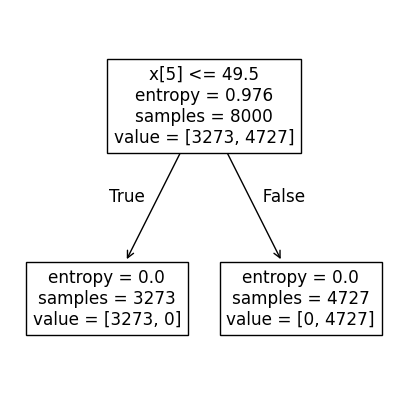

In [ ]:
#display decision tree
from sklearn import tree
plt.figure(figsize=(5,5))
tree.plot_tree(model)
plt.show()

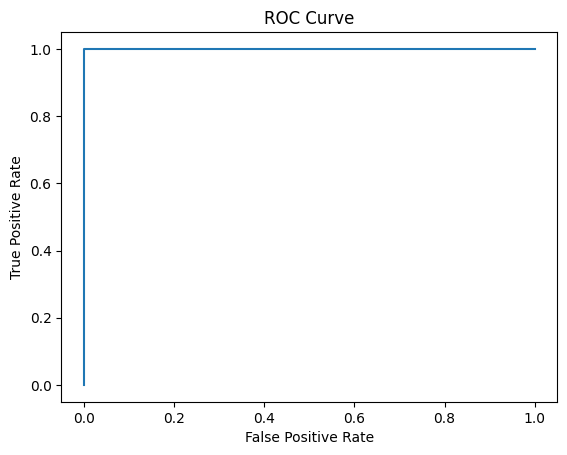

In [ ]:
#roc_curve
from sklearn.metrics import roc_curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred)
plt.plot(fpr, tpr)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.show()